In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report

In [2]:
!pip install polars

import polars as pl

In [3]:
def plot_histogram(df, column, bins=50, title=None, xlabel=None, ylabel="Frequency", yscale ='linear'):
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    plt.figure()
    plt.hist(df[column], bins=bins, edgecolor='black')
    plt.title(title or f"Histogram of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.grid(True)
    plt.show()

def plot_histogram_by_type(df, value_column, type_column="type", bins=50, alpha=0.7, filename = 'default_file', title = None):
    if value_column not in df.columns or type_column not in df.columns:
        raise ValueError(f"Columns '{value_column}' and/or '{type_column}' not found in DataFrame.")

    # Compute shared bin edges from entire column
    data = df[value_column].dropna()
    bin_edges = np.linspace(data.min(), data.max(), bins + 1)

    plt.figure(figsize=(8, 6))

    for t in df[type_column].unique():
        subset = df[df[type_column] == t][value_column].dropna()
        plt.hist(subset, bins=bin_edges, alpha=alpha, label=t, edgecolor='black', histtype='stepfilled')

    plt.xlabel(value_column)
    plt.ylabel("Frequency")
    plt.yscale('log')
    title = title or f"Histogram of {value_column} by {type_column} from {filename}"
    plt.title(title)
    plt.legend(title=type_column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Physics Helper Functions (from original script) ---

def delta_phi(phi1, phi2):
    """Computes the difference in phi, handling the wrap-around at pi."""
    # Ensure inputs are numpy arrays for broadcasting
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi

def delta_r(eta1, eta2, phi1, phi2):
    """Computes the delta R distance between two objects."""
    deta = np.asarray(eta1) - np.asarray(eta2)
    dphi = delta_phi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)



In [4]:
# --- Configuration ---
DATA_DIR = 'data_filtered'

In [5]:
import polars as pl

# Polars reads parquet files incredibly fast
df_sig_fjc = pl.read_parquet(f"{DATA_DIR}/signal_df_fjc.parquet")
# You can convert back to pandas if you absolutely need to:
# 

In [6]:
df_bg280_fjc = pl.read_parquet(f"{DATA_DIR}/background_280_df_fjc.parquet")
df_bg500_fjc = pl.read_parquet(f"{DATA_DIR}/background_500_df_fjc.parquet")
df_bg1000_fjc = pl.read_parquet(f"{DATA_DIR}/background_1000_df_fjc.parquet")



In [7]:
df_sig_fj = pl.read_parquet(f"{DATA_DIR}/signal_df_fj.parquet")
df_bg280_fj = pl.read_parquet(f"{DATA_DIR}/background_280_df_fj.parquet")
df_bg500_fj = pl.read_parquet(f"{DATA_DIR}/background_500_df_fj.parquet")
df_bg1000_fj = pl.read_parquet(f"{DATA_DIR}/background_1000_df_fj.parquet")

In [8]:
df_sig_fjc_truth = df_sig_fjc.to_pandas()

In [9]:
df_bg280_fjc_truth = df_bg280_fjc.to_pandas()
df_bg500_fjc_truth = df_bg500_fjc.to_pandas()
df_bg1000_fjc_truth = df_bg1000_fjc.to_pandas()



In [10]:
df_sig_fj_truth = df_sig_fj.to_pandas()
df_bg280_fj_truth = df_bg280_fj.to_pandas()
df_bg500_fj_truth = df_bg500_fj.to_pandas()
df_bg1000_fj_truth = df_bg1000_fj.to_pandas()

In [12]:
df_bkg_reco = pl.read_parquet("data_reco/df_bkg.parquet")

In [13]:
df_sig_reco = pl.read_parquet("data_reco/df_sig.parquet")

In [14]:
df_bkg_reco = df_bkg_reco.to_pandas()

In [15]:
df_sig_reco = df_sig_reco.to_pandas()

In [17]:
df_bkg_reco

,numOfInDetTracks,numOfFatJets,fatJetPt,fatJetEta,fatJetPhi,fatJetM,fatJetD2,jet1Pt,jet1Eta,jet1Phi,...,fj_track28dPhi,fj_track28dR,fj_track29Pt,fj_track29dEta,fj_track29dPhi,fj_track29dR,fj_track30Pt,fj_track30dEta,fj_track30dPhi,fj_track30dR
0,1146,2,141.681885,-0.755780,2.302538,32.645485,1.188878,388.621429,1.544551,-1.378797,...,0.830074,0.910904,1.324698,0.190807,0.680781,0.707015,1.316154,0.798566,0.204051,0.824223
1,457,2,170.563339,-0.181642,1.881791,99.349762,1.281768,483.733704,1.488115,-1.494999,...,0.355835,0.772101,1.264027,0.647333,0.412634,0.767663,1.236781,0.627424,0.690648,0.933090
2,656,2,160.101746,0.888003,0.206463,19.512146,3.230738,283.821808,1.196497,-2.977778,...,0.642802,0.821591,1.203762,0.595779,0.567200,0.822598,1.197119,0.496527,0.219923,0.543052
3,784,2,274.733215,1.795040,2.339992,34.936996,1.324284,278.623108,1.804152,2.321295,...,0.008460,0.090526,3.859681,0.042803,0.012513,0.044594,3.681470,0.094537,0.107263,0.142977
4,560,2,136.314636,1.386221,-0.510110,66.818558,1.089629,349.059570,0.557356,-2.726790,...,0.353948,0.582272,4.952266,0.151159,0.112991,0.188722,4.933970,0.248024,0.439273,0.504457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518157,401,3,129.392685,0.568262,-1.025304,13.828302,1.155680,323.147919,-1.115143,2.369383,...,0.217494,0.474782,1.303572,0.529079,0.730808,0.902222,1.275516,0.807487,0.010629,0.807557
518158,683,3,226.605850,-1.167407,1.649799,12.092829,2.964571,383.438263,0.038504,-1.373429,...,0.102029,0.259621,1.140332,0.376290,0.322180,0.495372,1.113804,0.375072,0.389908,0.541025
518159,762,2,311.849976,0.426989,2.850860,14.566364,2.904703,324.913208,0.437605,2.849458,...,0.007523,0.044863,1.404571,0.861048,0.144556,0.873098,1.339669,0.902666,0.069002,0.905300
518160,533,2,330.719269,-1.269899,-1.357650,165.888550,1.594207,402.975098,-0.380890,1.829826,...,0.213523,0.639074,1.306226,0.112633,0.695884,0.704941,1.303771,0.500507,0.618180,0.795395


In [20]:
def split_by_prefix(df):
    # 1. Columns starting with 'fj_track'
    fj_track_cols = [c for c in df.columns if c.startswith('fj_track')]
    
    # 2. Columns starting with 'fatJet'
    fatjet_cols = [c for c in df.columns if c.startswith('fatJet')]
    
    # 3. Everything else (the remainder)
    other_cols = [c for c in df.columns if not c.startswith('fj_track') 
                  and not c.startswith('fatJet')]
    
    return df[fj_track_cols], df[fatjet_cols], df[other_cols]

# Apply the split to both DataFrames
df_bkg_fjc_reco, df_bkg_fj_reco, df_bkg_misc_reco = split_by_prefix(df_bkg_reco)
df_sig_fjc_reco, df_sig_fj_reco, df_sig_misc_reco = split_by_prefix(df_sig_reco)

In [21]:
df_bkg_fjc_reco

,fj_track1Pt,fj_track1dEta,fj_track1dPhi,fj_track1dR,fj_track2Pt,fj_track2dEta,fj_track2dPhi,fj_track2dR,fj_track3Pt,fj_track3dEta,...,fj_track28dPhi,fj_track28dR,fj_track29Pt,fj_track29dEta,fj_track29dPhi,fj_track29dR,fj_track30Pt,fj_track30dEta,fj_track30dPhi,fj_track30dR
0,179.774521,0.111936,0.727000,0.735567,17.064953,0.130039,0.018514,0.131350,10.529247,0.244406,...,0.830074,0.910904,1.324698,0.190807,0.680781,0.707015,1.316154,0.798566,0.204051,0.824223
1,168.944611,0.647087,0.208369,0.679809,19.434944,0.404674,0.144638,0.429745,7.092302,0.170672,...,0.355835,0.772101,1.264027,0.647333,0.412634,0.767663,1.236781,0.627424,0.690648,0.933090
2,132.834351,0.094888,0.416944,0.427605,35.858208,0.006370,0.032551,0.033169,35.348595,0.024978,...,0.642802,0.821591,1.203762,0.595779,0.567200,0.822598,1.197119,0.496527,0.219923,0.543052
3,78.379921,0.024712,0.062388,0.067104,36.836658,0.097826,0.057421,0.113433,31.247850,0.067527,...,0.008460,0.090526,3.859681,0.042803,0.012513,0.044594,3.681470,0.094537,0.107263,0.142977
4,3187.883545,0.153924,0.288796,0.327255,149.440720,0.159403,0.125011,0.202576,53.173233,0.150649,...,0.353948,0.582272,4.952266,0.151159,0.112991,0.188722,4.933970,0.248024,0.439273,0.504457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518157,57.405212,0.083337,0.015839,0.084828,19.305042,0.067406,0.048759,0.083192,18.466667,0.097324,...,0.217494,0.474782,1.303572,0.529079,0.730808,0.902222,1.275516,0.807487,0.010629,0.807557
518158,60.097469,0.014305,0.001988,0.014442,22.548197,0.019067,0.019438,0.027228,17.984682,0.002328,...,0.102029,0.259621,1.140332,0.376290,0.322180,0.495372,1.113804,0.375072,0.389908,0.541025
518159,92.626022,0.002521,0.002275,0.003396,26.958376,0.860163,0.377285,0.939268,18.323996,0.090418,...,0.007523,0.044863,1.404571,0.861048,0.144556,0.873098,1.339669,0.902666,0.069002,0.905300
518160,27.413057,0.099965,0.124232,0.159457,18.655750,0.066800,0.244617,0.253573,14.188510,0.079252,...,0.213523,0.639074,1.306226,0.112633,0.695884,0.704941,1.303771,0.500507,0.618180,0.795395


In [27]:
df_sig_fj_truth

,eta,phi,pt,m,D2,event_index,index,count,__index_level_0__
0,-1.305899,-1.758322,341919.72,93334.970,0.179063,7,1,30,4
1,-1.914104,2.719653,254758.03,113848.510,0.220359,13,0,40,7
2,-0.462934,1.712915,266244.75,92070.350,0.170285,17,1,19,10
3,2.067106,0.045983,277440.12,86642.766,0.094879,19,0,22,12
4,-0.721390,1.515283,255669.81,63837.137,0.144465,20,1,23,13
...,...,...,...,...,...,...,...,...,...
895791,1.452749,1.793147,206052.23,85969.390,0.246243,2499992,1,38,1780722
895792,-1.058212,2.353608,243838.50,91727.050,0.325370,2499993,1,52,1780723
895793,0.393330,2.407941,347613.62,8353.568,0.291007,2499994,1,23,1780724
895794,-1.150656,2.392028,257891.03,89924.220,0.143167,2499996,1,27,1780725


In [28]:
def delta_phi(phi1, phi2):
    """Calculates dPhi and wraps it strictly between -pi and pi."""
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi

def flatten_jet_constituents(df_fjc, df_fj, max_tracks=30):
    # 1. Isolate necessary columns from the Fat Jet dataframe
    fj_kinematics = df_fj[['event_index', 'eta', 'phi']].copy()
    fj_kinematics.rename(columns={'eta': 'eta_fj', 'phi': 'phi_fj'}, inplace=True)

    # 2. Merge constituent (fjc) data with parent fat jet (fj) data
    merged = pd.merge(df_fjc, fj_kinematics, on='event_index', how='inner')

    # 3. Calculate relative kinematics (dEta, dPhi, dR)
    merged['dEta'] = merged['eta'] - merged['eta_fj']
    merged['dPhi'] = delta_phi(merged['phi'], merged['phi_fj'])
    merged['dR']   = np.sqrt(merged['dEta']**2 + merged['dPhi']**2)

    # 4. Sort by event_index and constituent pT (highest first)
    merged = merged.sort_values(by=['event_index', 'pt'], ascending=[True, False])

    # 5. Assign a rank/track number to each constituent within its event
    merged['track_num'] = merged.groupby('event_index').cumcount() + 1

    # 6. Truncate to keep only the top 'max_tracks'
    merged = merged[merged['track_num'] <= max_tracks]

    # 7. Pivot the data to go from "long" to "wide" (flat) format
    #    Add any other constituent variables you need (like 'm') to the values list.
    pivoted = merged.pivot(
        index='event_index', 
        columns='track_num', 
        values=['pt', 'dEta', 'dPhi', 'dR']
    )

    # 8. Rename the multi-level columns to match your exact required format
    new_cols = []
    for var, num in pivoted.columns:
        # Match the specific capitalization/naming requested
        if var == 'pt':
            new_cols.append(f'fj_track{num}Pt')
        else:
            new_cols.append(f'fj_track{num}{var}')
    pivoted.columns = new_cols

    # 9. Ensure all 30 tracks exist in the dataframe (for padding)
    expected_cols = []
    for i in range(1, max_tracks + 1):
        expected_cols.extend([f'fj_track{i}Pt', f'fj_track{i}dEta', f'fj_track{i}dPhi', f'fj_track{i}dR'])
    
    # Reindex to enforce column order and add missing columns as NaNs
    pivoted = pivoted.reindex(columns=expected_cols)

    # 10. Realign with the original fat jet list to preserve empty jets, then pad with 0s
    out_df = df_fj[['event_index']].drop_duplicates().set_index('event_index')
    out_df = out_df.join(pivoted).fillna(0)

    # Drop the event_index if you just want a pure feature matrix, or keep it via reset_index()
    return out_df.reset_index(drop=True)

In [29]:
df_sig_fjc_truth_flat = flatten_jet_constituents(df_sig_fjc_truth, df_sig_fj_truth)

In [31]:
df_bg280_fjc_truth_flat = flatten_jet_constituents(df_bg280_fjc_truth, df_bg280_fj_truth)

In [ ]:
df_bg500_fjc_truth_flat = flatten_jet_constituents(df_bg500_fjc_truth, df_bg500_fj_truth)

In [33]:
df_bg1000_fjc_truth_flat = flatten_jet_constituents(df_bg1000_fjc_truth, df_bg1000_fj_truth)

In [124]:
df_bkg_fjc_reco[df_bkg_fjc_reco['fj_track1dR']>0.95]['fj_track1dR','fj_track2dR',

,fj_track1Pt,fj_track1dEta,fj_track1dPhi,fj_track1dR,fj_track2Pt,fj_track2dEta,fj_track2dPhi,fj_track2dR,fj_track3Pt,fj_track3dEta,...,fj_track28dPhi,fj_track28dR,fj_track29Pt,fj_track29dEta,fj_track29dPhi,fj_track29dR,fj_track30Pt,fj_track30dEta,fj_track30dPhi,fj_track30dR
47,154.009583,0.442500,0.876234,0.981627,44.948940,0.042083,0.015148,0.044726,43.638733,0.039949,...,0.064604,0.750220,1.028857,0.464457,0.727679,0.863271,0.971151,0.485127,0.514405,0.707079
76,62.933296,0.966530,0.237749,0.995341,45.831863,0.042210,0.020960,0.047127,17.729464,0.004504,...,0.335531,0.764357,1.269052,0.508233,0.506250,0.717349,1.256882,0.867900,0.245526,0.901961
95,216.739029,0.882659,0.367977,0.956292,18.447401,0.022916,0.024209,0.033335,14.391904,0.027517,...,0.862972,0.914908,1.236935,0.032100,0.508892,0.509903,1.161409,0.389015,0.365349,0.533678
111,37.757610,0.794845,0.548267,0.965595,29.471159,0.012363,0.223790,0.224131,20.644741,0.048637,...,0.643699,0.664298,1.672614,0.099642,0.994574,0.999553,1.638423,0.172004,0.304793,0.349978
128,121.104668,0.227805,0.932725,0.960142,51.881512,0.041505,0.049869,0.064881,19.269171,0.005014,...,0.269570,0.386349,1.195230,0.044586,0.704752,0.706161,1.195080,0.839401,0.156386,0.853845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517955,69.883835,0.971154,0.004923,0.971166,25.466028,0.204537,0.000040,0.204537,14.121382,0.101815,...,0.393411,0.546012,1.123960,0.204106,0.435511,0.480967,1.119701,0.097666,0.490883,0.500504
518015,40.359753,0.959868,0.173424,0.975409,28.503407,0.020477,0.009367,0.022518,20.029665,0.027346,...,0.206574,0.583899,0.945466,0.261695,0.461842,0.530832,0.942192,0.448805,0.826889,0.940836
518051,123.994003,0.879500,0.436160,0.981710,24.608906,0.026617,0.035351,0.044251,23.211967,0.013471,...,0.908857,0.916757,0.726608,0.691238,0.073890,0.695176,0.724189,0.616269,0.358202,0.712809
518061,1.394408,0.011643,0.965688,0.965758,1.337088,0.339922,0.118059,0.359840,1.301626,0.583114,...,0.435163,0.735812,0.550049,0.242377,0.645661,0.689655,0.544366,0.288396,0.118591,0.311827


In [94]:
def scale_track_pt(df):
    """Divides fj_track1Pt through fj_track30Pt by 1000."""
    
    # 1. Generate the exact list of target column names
    pt_columns = [f'fj_track{i}Pt' for i in range(1, 31)]
    
    # 2. Filter for columns that actually exist in the dataframe 
    # (This prevents KeyErrors if a dataframe happens to have fewer than 30 tracks)
    cols_to_scale = [col for col in pt_columns if col in df.columns]
    
    # 3. Apply the division efficiently across all selected columns
    df[cols_to_scale] = df[cols_to_scale] / 1000.0
    
    return df

def abs_track_eta_phi(df):
    """Divides fj_track1Pt through fj_track30Pt by 1000."""
    
    # 1. Generate the exact list of target column names
    eta_columns = [f'fj_track{i}dEta' for i in range(1, 31)]
    phi_columns = [f'fj_track{i}dPhi' for i in range(1, 31)]
    
    # 2. Filter for columns that actually exist in the dataframe 
    # (This prevents KeyErrors if a dataframe happens to have fewer than 30 tracks)
    cols_to_scale = [col for col in eta_columns if col in df.columns] + [col for col in phi_columns if col in df.columns]
    
    # 3. Apply the division efficiently across all selected columns
    df[cols_to_scale] = np.abs(df[cols_to_scale])
    
    return df

    
# Example usage:
# df_sig_final = scale_track_pt(df_sig_final)
# df_bkg_final = scale_track_pt(df_bkg_final)

In [46]:
df_sig_fjc_truth_flat = scale_track_pt(df_sig_fjc_truth_flat)
df_bg280_fjc_truth_flat = scale_track_pt(df_bg280_fjc_truth_flat)
df_bg500_fjc_truth_flat = scale_track_pt(df_bg500_fjc_truth_flat)
df_bg1000_fjc_truth_flat = scale_track_pt(df_bg1000_fjc_truth_flat)

In [47]:
abs_track_eta_phi

In [95]:
df_sig_fjc_truth_flat = abs_track_eta_phi(df_sig_fjc_truth_flat)
df_bg280_fjc_truth_flat = abs_track_eta_phi(df_bg280_fjc_truth_flat)
df_bg500_fjc_truth_flat = abs_track_eta_phi(df_bg500_fjc_truth_flat)
df_bg1000_fjc_truth_flat = abs_track_eta_phi(df_bg1000_fjc_truth_flat)

In [97]:
# Assuming your four DataFrames are already loaded in memory

# Save each DataFrame to a Parquet file
df_sig_fjc_truth_flat.to_parquet('df_sig_fjc_truth_flat.parquet', engine='pyarrow')
df_bg280_fjc_truth_flat.to_parquet('df_bg280_fjc_truth_flat.parquet', engine='pyarrow')
df_bg500_fjc_truth_flat.to_parquet('df_bg500_fjc_truth_flat.parquet', engine='pyarrow')
df_bg1000_fjc_truth_flat.to_parquet('df_bg1000_fjc_truth_flat.parquet', engine='pyarrow')

print("All DataFrames successfully saved as Parquet files.")

All DataFrames successfully saved as Parquet files.


In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_histogram_diffs(df1: pd.DataFrame, df2: pd.DataFrame, columns: list, 
                         log_scale: bool = False, n_bins: int = 50, 
                         df1_label: str = 'DataFrame 1', df2_label: str = 'DataFrame 2',
                         min_freq: float = 1e-7, max_x_cap: float = 1000.0):
    """
    Plots overlaid normalized histograms for selected columns from two DataFrames.
    Filters out exact zeros, discards values above max_x_cap, removes bins below min_freq, 
    and zooms the x-axis to fit the remaining valid data.
    """
    for col in columns:
        if col not in df1.columns or col not in df2.columns:
            print(f"Warning: Column '{col}' not found in both DataFrames. Skipping.")
            continue

        # 1. Clean data: Drop NaNs, exact zeros, and apply the max_x_cap
        data1 = df1[col].dropna()
        data1 = data1[(data1 != 0.0) & (data1 <= max_x_cap)]
        
        data2 = df2[col].dropna()
        data2 = data2[(data2 != 0.0) & (data2 <= max_x_cap)]

        if len(data1) == 0 or len(data2) == 0:
            print(f"Warning: Column '{col}' has no valid data after filtering (zeros and >{max_x_cap} removed). Skipping.")
            continue

        # 2. Determine shared bins based on the capped data
        min_val = min(data1.min(), data2.min())
        max_val = max(data1.max(), data2.max())
        bins = np.linspace(min_val, max_val, n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        width = bins[1] - bins[0]

        # 3. Calculate raw counts using numpy
        counts1, _ = np.histogram(data1, bins=bins)
        counts2, _ = np.histogram(data2, bins=bins)

        # 4. Filter and Rescale to Density
        # --- For DataFrame 1 ---
        freq1 = counts1 / counts1.sum()
        filtered_freq1 = np.where(freq1 >= min_freq, freq1, 0)
        
        if filtered_freq1.sum() > 0:
            density1 = (filtered_freq1 / filtered_freq1.sum()) / width
        else:
            density1 = np.zeros_like(filtered_freq1)

        # --- For DataFrame 2 ---
        freq2 = counts2 / counts2.sum()
        filtered_freq2 = np.where(freq2 >= min_freq, freq2, 0)
        
        if filtered_freq2.sum() > 0:
            density2 = (filtered_freq2 / filtered_freq2.sum()) / width
        else:
            density2 = np.zeros_like(filtered_freq2)

        # 5. Determine the new x-axis bounds based on surviving bins
        valid_bins_mask = (density1 > 0) | (density2 > 0)
        
        if not valid_bins_mask.any():
            print(f"Warning: No bins survived the {min_freq} threshold for column '{col}'. Skipping.")
            continue
            
        valid_indices = np.where(valid_bins_mask)[0]
        first_valid_idx = valid_indices[0]
        last_valid_idx = valid_indices[-1]
        
        x_min_zoom = bins[first_valid_idx]
        x_max_zoom = bins[last_valid_idx + 1]

        # 6. Calculate the difference (DF1 - DF2)
        hist_diff = density1 - density2

        # 7. Set up the figure and subplots
        fig, (ax1, ax2) = plt.subplots(
            nrows=2, ncols=1, figsize=(10, 8), 
            sharex=True, gridspec_kw={'height_ratios': [2, 1]}
        )

        # --- Top Subplot: Overlaid Histograms ---
        ax1.bar(bin_centers, density1, width=width, alpha=0.5, label=df1_label, color='blue', edgecolor='white', linewidth=0.5)
        ax1.bar(bin_centers, density2, width=width, alpha=0.5, label=df2_label, color='orange', edgecolor='white', linewidth=0.5)
        
        if log_scale:
            ax1.set_yscale('log')
            valid_densities = np.concatenate([density1[density1 > 0], density2[density2 > 0]])
            if len(valid_densities) > 0:
                ax1.set_ylim(bottom=valid_densities.min() * 0.5)
                
        # Apply the zoomed x-axis limits here
        ax1.set_xlim(x_min_zoom, x_max_zoom)
            
        ax1.set_ylabel('Normalized Density')
        ax1.set_title(f'Distribution Comparison: {col} (Zeros removed)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # --- Bottom Subplot: Difference ---
        diff_colors = ['blue' if val > 0 else 'orange' for val in hist_diff]
        ax2.bar(bin_centers, hist_diff, width=width, color=diff_colors, alpha=0.7)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        
        ax2.set_ylabel(f'Difference\n({df1_label} - {df2_label})')
        ax2.set_xlabel(col)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

In [69]:
plot_histogram_diffs(df1: pd.DataFrame, df2: pd.DataFrame, columns: list, 
                         log_scale: bool = False, n_bins: int = 50, 
                         df1_label: str = 'DataFrame 1', df2_label: str = 'DataFrame 2',
                         min_freq: float = 1e-7)

SyntaxError: invalid syntax (31492634.py, line 1)

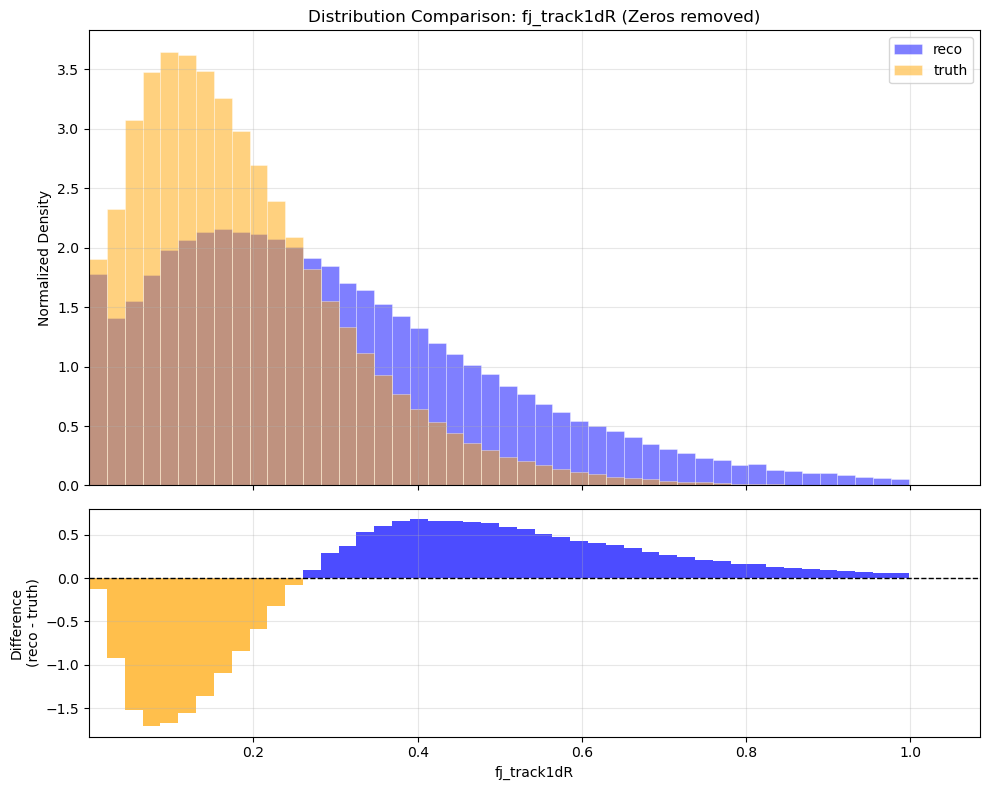

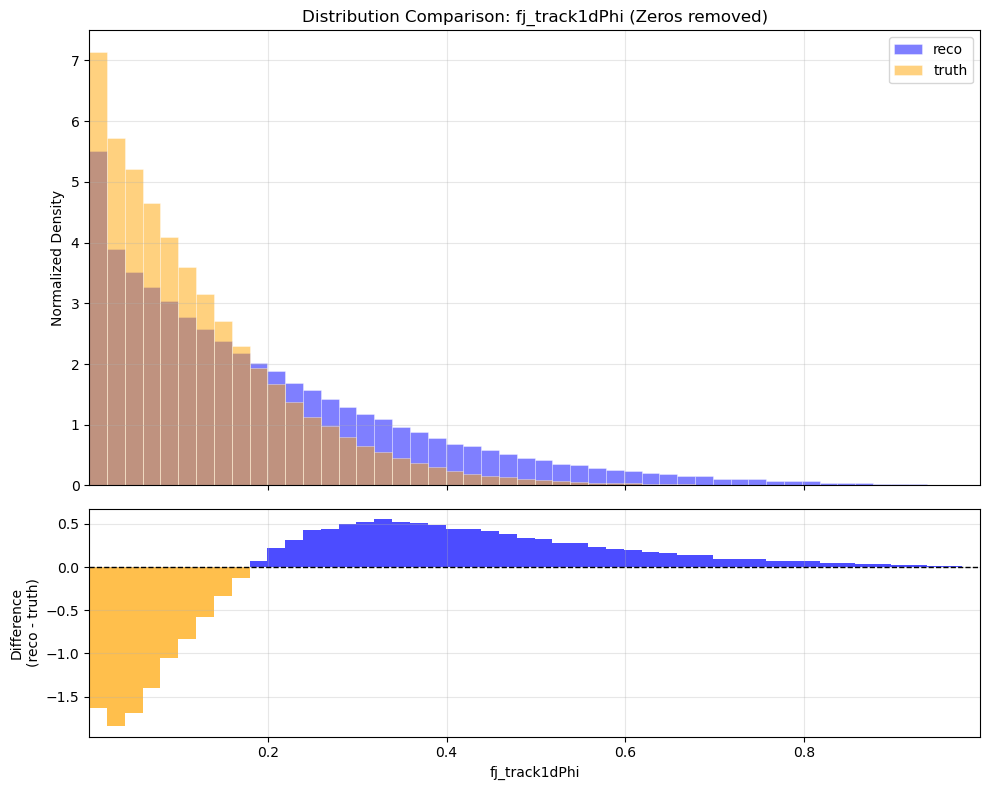

In [105]:
plot_histogram_diffs(df_sig_fjc_reco, df_sig_fjc_truth_flat, ['fj_track1dEta', 'fj_track1dPhi'],
                     log_scale=False, df1_label = "reco", df2_label = "truth", min_freq = 0, max_x_cap = 500)

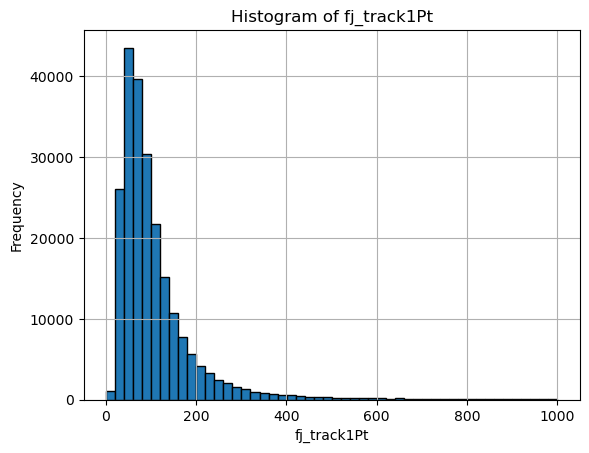

In [79]:
plot_histogram(df_sig_fjc_reco[df_sig_fjc_reco['fj_track1Pt']<1000], 'fj_track1Pt')

In [98]:
df_bkg_fjc_truth_flat = pd.concat([df_bg280_fjc_truth_flat, df_bg500_fjc_truth_flat, df_bg1000_fjc_truth_flat], ignore_index=True)

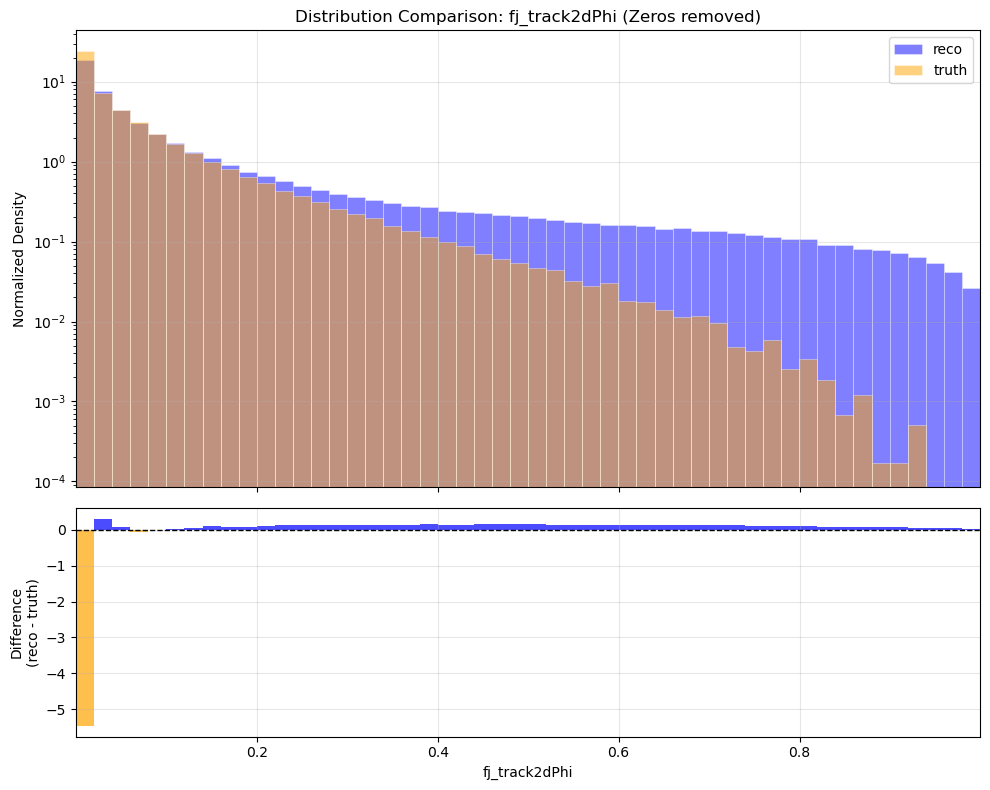

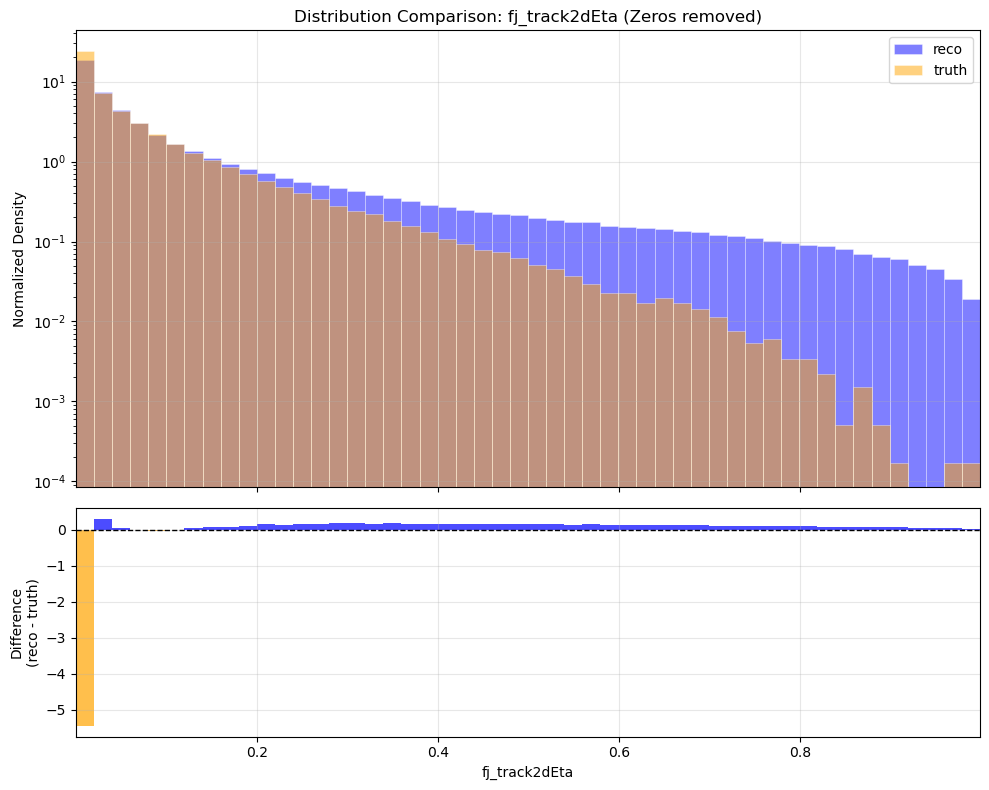

In [125]:
plot_histogram_diffs(df_bkg_fjc_reco, df_bkg_fjc_truth_flat, ['fj_track2dPhi', 'fj_track2dEta'],
                     log_scale=True, df1_label = "reco", df2_label = "truth", min_freq = 0, max_x_cap = 500)

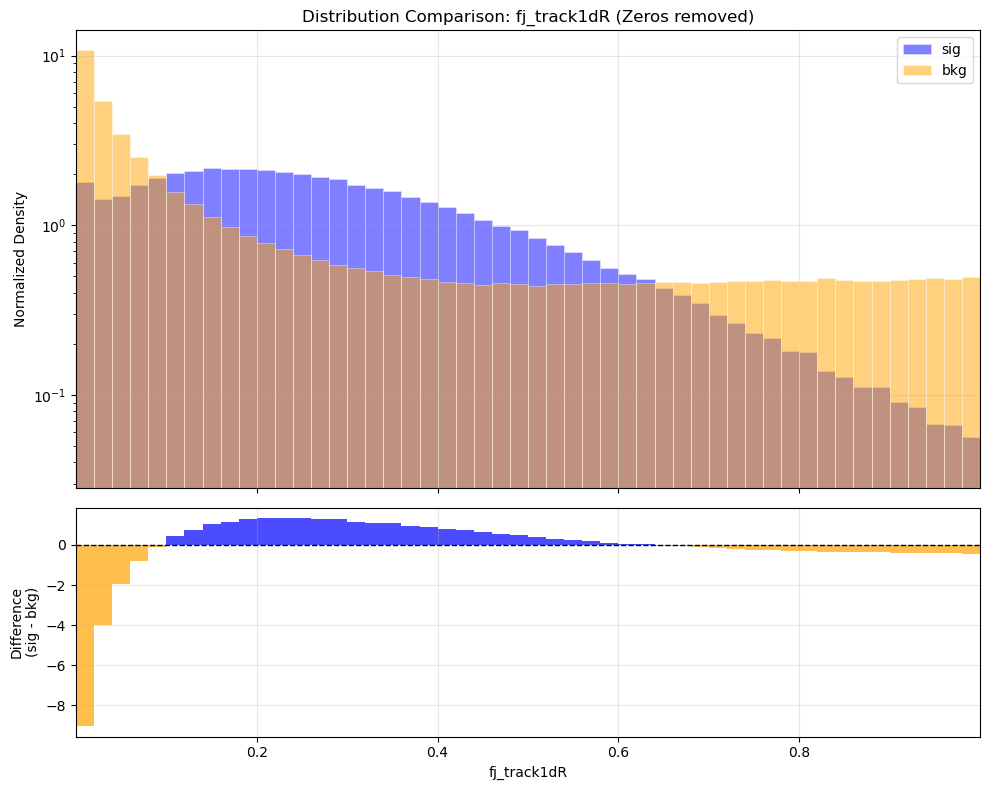

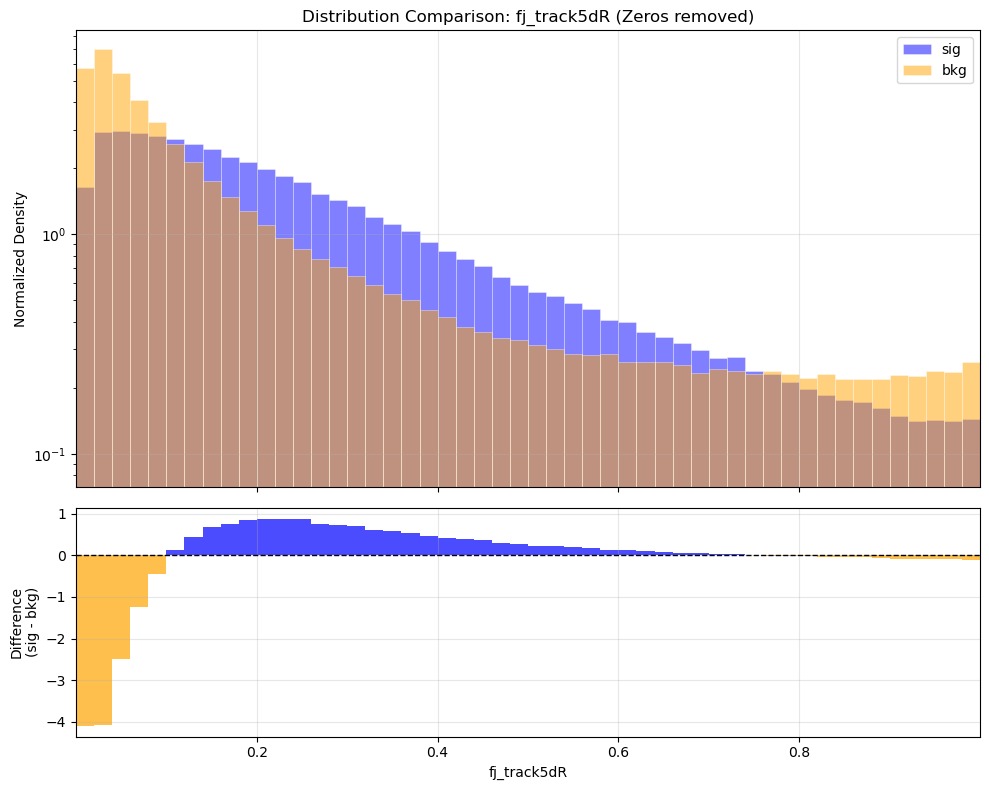

In [129]:
plot_histogram_diffs(df_sig_fjc_reco, df_bkg_fjc_reco, ['fj_track1dR', 'fj_track5dR'],
                     log_scale=True, df1_label = "sig", df2_label = "bkg", min_freq = 0, max_x_cap = 500)

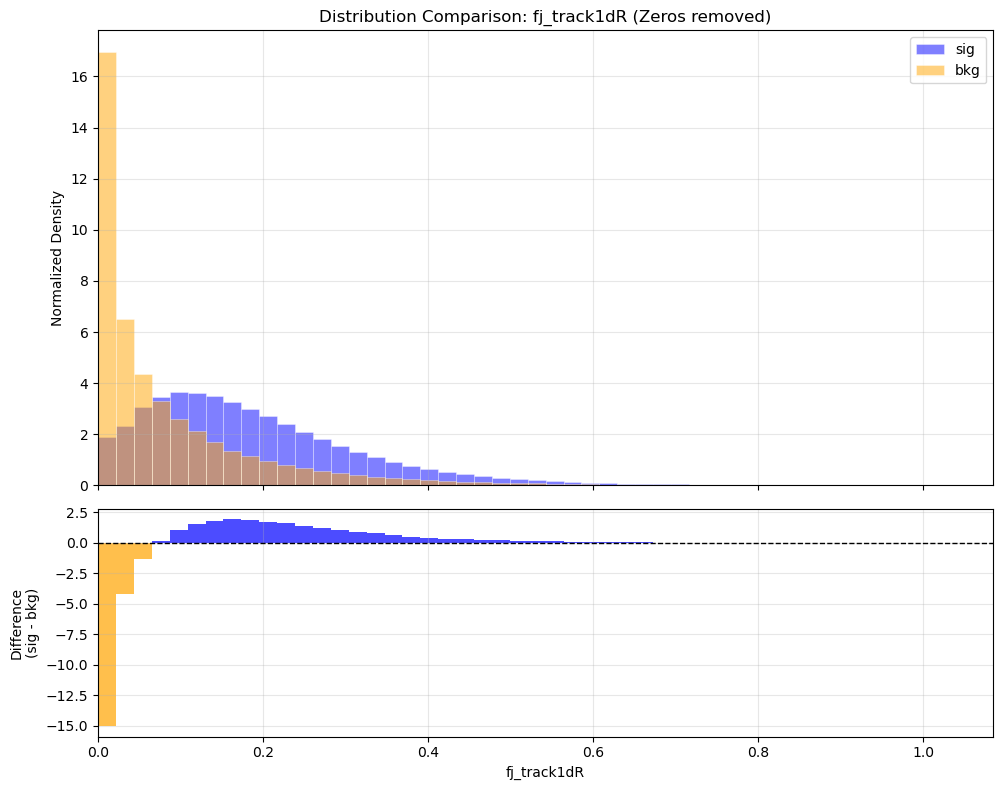

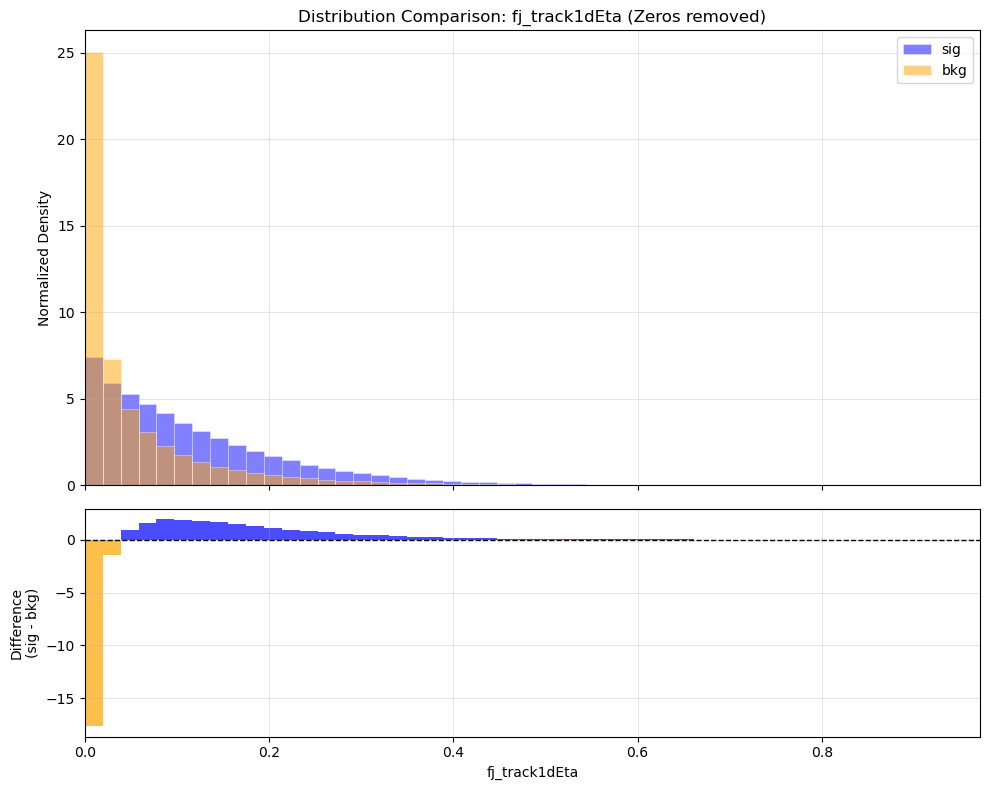

In [113]:
plot_histogram_diffs(df_sig_fjc_truth_flat, df_bkg_fjc_truth_flat, ['fj_track1dR', 'fj_track1dEta'],
                     log_scale=False, df1_label = "sig", df2_label = "bkg", min_freq = 0, max_x_cap = 500)